<a href="https://colab.research.google.com/github/ilinkabibic/Tom-and-Jerry-Character-Classification/blob/main/notebooks/08_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 08 — Demo (za odbranu)

Live klasifikacija JEDNE slike koristeći sva 4 sačuvana modela (Random Forest, SVM, CNN od nule,
Transfer learning ResNet18), plus Grad-CAM vizuelizacija za najbolji model (gdje model "gleda" na slici).

Koristi se `demo/frame1794.jpg` — slika iz `challenges.csv` (pravi held-out skup, iz 07),
koju su tačno pogodila 2 od 4 naša modela (CNN i ResNet18 tačno, RF i SVM pogrešno) —
odlična ilustracija razlika između modela na jednoj konkretnoj, teškoj slici.

- **Cilj:** brz, pouzdan demo bez čekanja — samo učitavanje sačuvanih modela i jedne slike, bez treninga
- **Modeli:** sva 4 (RF, SVM, CNN, ResNet18) za klasifikaciju; ResNet18 dodatno za Grad-CAM

### 1. Priprema — kloniranje repo-a (model i demo slika)

In [1]:
username = "ilinkabibic"
repo_name = "Tom-and-Jerry-Character-Classification"

!git clone https://github.com/{username}/{repo_name}.git
%cd {repo_name}

print("Demo slika:", __import__('os').listdir('demo'))
print("Modeli:", __import__('os').listdir('models'))

Cloning into 'Tom-and-Jerry-Character-Classification'...
remote: Enumerating objects: 140, done.
remote: Counting objects: 100% (28/28), done.
remote: Compressing objects: 100% (25/25), done.
remote: Total 140 (delta 15), reused 6 (delta 2), pack-reused 112 (from 2)
Receiving objects: 100% (140/140), 237.57 MiB | 30.02 MiB/s, done.
Resolving deltas: 100% (64/64), done.
Updating files: 100% (16/16), done.
/content/Tom-and-Jerry-Character-Classification
Demo slika: ['frame1794.jpg']
Modeli: ['cnn_scratch.pt', 'resnet18_transfer.pt', 'rf_final.joblib', 'svm_scaler.joblib', 'svm_final.joblib']


### 2. Učitavanje sva 4 modela

In [2]:
import torch, torch.nn as nn, torch.nn.functional as F
from torchvision import models
import joblib

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# --- klasicni modeli ---
rf = joblib.load('models/rf_final.joblib')
svm = joblib.load('models/svm_final.joblib')
scaler = joblib.load('models/svm_scaler.joblib')

# --- CNN od nule ---
IMG_SIZE = 64
class SmallCNN(nn.Module):
    def __init__(self, n):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.pool = nn.MaxPool2d(2); self.dropout = nn.Dropout(0.3)
        self.fc1 = nn.Linear(128 * (IMG_SIZE//8) * (IMG_SIZE//8), 128)
        self.fc2 = nn.Linear(128, n)
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = torch.flatten(x, 1)
        x = self.dropout(F.relu(self.fc1(x)))
        return self.fc2(x)

cnn = SmallCNN(4).to(device)
cnn.load_state_dict(torch.load('models/cnn_scratch.pt', map_location=device))
cnn.eval()
cnn_idx = {0: 'both', 1: 'jerry', 2: 'neither', 3: 'tom'}

# --- Transfer learning ResNet18 ---
resnet = models.resnet18(weights=None)
resnet.fc = nn.Linear(resnet.fc.in_features, 4)
resnet.load_state_dict(torch.load('models/resnet18_transfer.pt', map_location=device))
resnet = resnet.to(device)
resnet.eval()
res_idx = {0: 'tom', 1: 'jerry', 2: 'both', 3: 'neither'}

print("Sva 4 modela učitana.")

Sva 4 modela učitana.


### 3. Klasifikacija demo slike — sva 4 modela uživo

Stvarna klasa: jerry

Random Forest:  tom
SVM:            both
CNN od nule:    jerry
ResNet18:       jerry


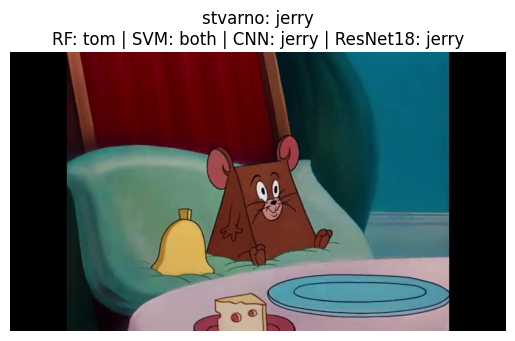

In [3]:
import pandas as pd, numpy as np
from PIL import Image
import torchvision.transforms as T
import matplotlib.pyplot as plt

DEMO_FILENAME = 'frame1794.jpg'
DEMO_PATH = 'demo/frame1794.jpg'

# osobine za klasicne modele - vec postoje u features_hog_color.npy (nista ne racunamo ponovo)
split_df = pd.read_csv('data_split.csv')
X_all = np.load('features_hog_color.npy')
idx = split_df.index[split_df['filename'] == DEMO_FILENAME][0]
x_demo = X_all[idx:idx+1]
stvarno = split_df.loc[idx, 'class']

# --- klasicni modeli ---
pred_rf = rf.predict(x_demo)[0]
pred_svm = svm.predict(scaler.transform(x_demo))[0]

# --- duboki modeli ---
img = Image.open(DEMO_PATH).convert('RGB')

cnn_tf = T.Compose([T.Resize((64, 64)), T.ToTensor(), T.Normalize([0.5]*3, [0.5]*3)])
with torch.no_grad():
    out = cnn(cnn_tf(img).unsqueeze(0).to(device))
    pred_cnn = cnn_idx[out.argmax(1).item()]

res_tf = T.Compose([T.Resize((224, 224)), T.ToTensor(),
                    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])
with torch.no_grad():
    out = resnet(res_tf(img).unsqueeze(0).to(device))
    pred_res = res_idx[out.argmax(1).item()]

# --- ispis i prikaz ---
print(f"Stvarna klasa: {stvarno}\n")
print(f"Random Forest:  {pred_rf}")
print(f"SVM:            {pred_svm}")
print(f"CNN od nule:    {pred_cnn}")
print(f"ResNet18:       {pred_res}")

plt.imshow(img)
plt.axis('off')
plt.title(f"stvarno: {stvarno}\nRF: {pred_rf} | SVM: {pred_svm} | CNN: {pred_cnn} | ResNet18: {pred_res}")
plt.show()

### 4. Grad-CAM — gdje ResNet18 "gleda" na slici

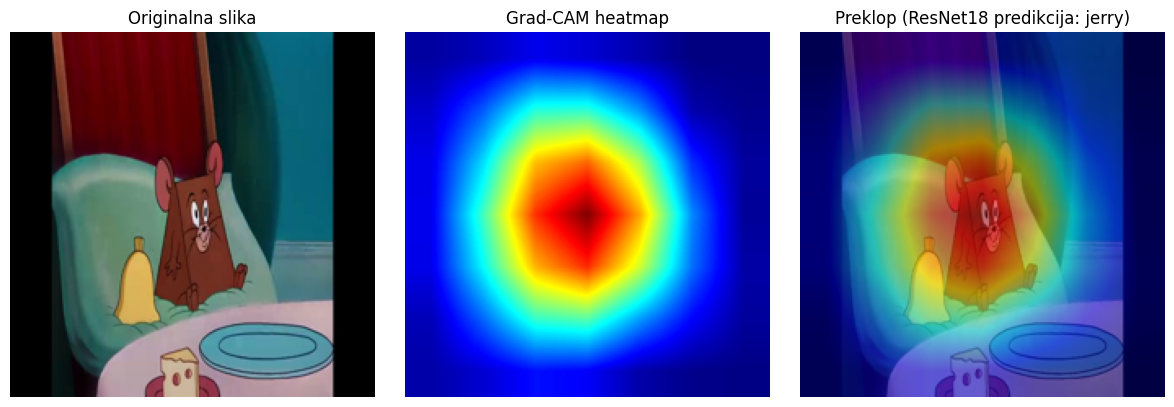

In [4]:
import torch.nn.functional as F
import numpy as np
import cv2

def grad_cam(model, img_tensor, target_class_idx, target_layer):
    activations = []
    gradients = []

    def forward_hook(module, input, output):
        activations.append(output)

    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0])

    h1 = target_layer.register_forward_hook(forward_hook)
    h2 = target_layer.register_full_backward_hook(backward_hook)

    model.zero_grad()
    output = model(img_tensor)
    score = output[0, target_class_idx]
    score.backward()

    h1.remove()
    h2.remove()

    act = activations[0].squeeze(0)
    grad = gradients[0].squeeze(0)
    weights = grad.mean(dim=(1, 2))

    cam = torch.zeros(act.shape[1:], dtype=torch.float32).to(act.device)
    for i, w in enumerate(weights):
        cam += w * act[i]
    cam = F.relu(cam)
    cam = cam.cpu().detach().numpy()
    cam = cv2.resize(cam, (224, 224))
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    return cam

res_input = res_tf(img).unsqueeze(0).to(device)
pred_idx = res_idx_inv = {v: k for k, v in res_idx.items()}[pred_res]  # nazad u broj
target_layer = resnet.layer4[-1]

cam = grad_cam(resnet, res_input, pred_idx, target_layer)

heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

img_224 = np.array(img.resize((224, 224)))
overlay = (0.5 * img_224 + 0.5 * heatmap).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(img_224); axes[0].set_title('Originalna slika'); axes[0].axis('off')
axes[1].imshow(heatmap); axes[1].set_title('Grad-CAM heatmap'); axes[1].axis('off')
axes[2].imshow(overlay); axes[2].set_title(f'Preklop (ResNet18 predikcija: {pred_res})'); axes[2].axis('off')
plt.tight_layout()
plt.show()

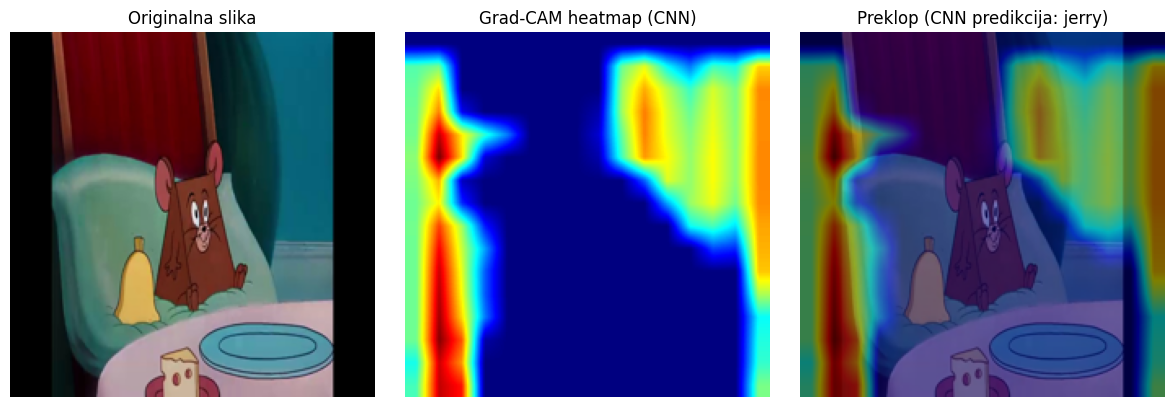

In [5]:
cnn_input = cnn_tf(img).unsqueeze(0).to(device)
pred_idx_cnn = {v: k for k, v in cnn_idx.items()}[pred_cnn]
target_layer_cnn = cnn.conv3

cam_cnn = grad_cam(cnn, cnn_input, pred_idx_cnn, target_layer_cnn)

heatmap_cnn = cv2.applyColorMap(np.uint8(255 * cam_cnn), cv2.COLORMAP_JET)
heatmap_cnn = cv2.cvtColor(heatmap_cnn, cv2.COLOR_BGR2RGB)

img_224 = np.array(img.resize((224, 224)))
overlay_cnn = (0.5 * img_224 + 0.5 * heatmap_cnn).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(img_224); axes[0].set_title('Originalna slika'); axes[0].axis('off')
axes[1].imshow(heatmap_cnn); axes[1].set_title('Grad-CAM heatmap (CNN)'); axes[1].axis('off')
axes[2].imshow(overlay_cnn); axes[2].set_title(f'Preklop (CNN predikcija: {pred_cnn})'); axes[2].axis('off')
plt.tight_layout()
plt.show()

## Zaključak — 08

Demo na slici `frame1794.jpg` (jerry, iz `challenges.csv`, pravi held-out skup) pokazuje razlike
između sva 4 modela na jednom konkretnom, teškom primeru:

- **RF i SVM su pogriješili** (RF: tom, SVM: both) — klasični modeli, sa ručno dizajniranim
  osobinama (HOG + boja), nisu uspjeli da razdvoje ovaj granični slučaj.
- **CNN i ResNet18 su tačno pogodili** (jerry) — oba duboka modela, koja uče osobine direktno
  iz piksela, bolje su se snašla ovdje.
- **Grad-CAM potvrđuje razliku između dva duboka modela**: ResNet18 se jasno fokusira na
  samog Jerry-ja, dok CNN (treniran od nule) dijelom "gleda" i u ivice/pozadinu slike — vjerovatno razlog zašto CNN treniran od nule (na svega ~3800 slika) generalizuje slabije od ResNet18 (pretreniran na milionima ImageNet slika) — bez tog "predznanja", CNN je sklon da nauči prečice/spurious korelacije umesto pravih vizuelnih osobina.
- Za RF i SVM Grad-CAM nije primjenljiv — ti modeli ne rade nad pikselima slike, već nad unaprijed
  izračunatim osobinama (HOG + histogram boja), pa nema kroz šta da se prate gradijenti unazad ka slici.